#  Supervised Learning Concepts & the Scikit-learn API 

### Introduction

In the previous two weeks, we focused on the data science side of machine learning. We learned how to work with datasets by loading, cleaning, exploring, and interpreting them using univariate and bivariate analysis.

Now that we have learned how to prepare and understand our data, we can move on to the next stage of the machine learning workflow: building models. In this notebook, we will begin learning about **supervised learning**, which is the first step toward training models to make predictions from data.


### Contents of this notebook:
- **Section 1: Supervised Learning** — definition and key features, Classification (with its types), Regression (with its types), and a Classification vs Regression comparison table.
- **Section 2: Scikit-learn** — what it is, the general model-building flow, and a first code walkthrough using the California Housing dataset.
- **Section 3: Hands-on Lab** — applying the workflow on the Heart Disease dataset (load data, split into `X`/`y`, train/test split, and reasoning about why the test set must stay unseen).
- **Section 4: References** — articles and tutorials used to build this notebook.

### Libraries used:
- **scikit-learn (`sklearn`)** — `datasets` (to load sample datasets), `neighbors` (`KNeighborsRegressor`), `linear_model` (`LinearRegression`), `model_selection` (`train_test_split`)
- **pandas** — reading and exploring the tabular dataset (`read_csv`, `.head()`, `.shape`)
- **numpy** — numerical operations on arrays
- **matplotlib** — plotting predictions vs actual values
- **seaborn** — data visualization

# Section 1: Supervised learning 

## Introduction

**Supervised learning** is a type of machine learning where a model learns from labelled data, meaning each input has a correct output. The model compares its predictions with actual results and improves over time to increase accuracy.

Main features :

- Each input has a known output
- Adjusts itself to reduce prediction errors
- Make accurate predictions on new data
- For example it recognizing handwritten digits from trained data

## 1. Classification


### Definition:
>  A supervised machine learning technique used to **predict labels or categories** from input data. **It assigns each data point to a predefined class** based on learned patterns.

### Types of Classification


> <div style="text-align: center;"> <img src="classification_types.png" alt="A descriptive summary of the photo" width="600" > </div>

#### 1.  Binary Classification
>  Simplest type of classification where **data is divided into two possible categories**. The model analyzes input features and decides which of the two classes the data belongs to
> 
> **key Characteristics:**
> - **Two classes only:** Each data point is assigned to one of two categories.
> - **Single final prediction:** The model selects one of the two classes for each input.
> - **Common examples:** Spam vs not spam emails, diseased vs healthy patients / cat or non-cat.


#### 2. Multi-Class Classification
> **Data is divided into more than two categories**. The model analyzes the input features and selects the class that best matches the data.
>
> **key Characteristics:**
> - **Multiple classes:** Each data point is assigned to one of several possible categories.
> - **Single final prediction:** The model selects only one class for each input.
> - **Common examples:** Image classification such as identifying animals like cat, dog or bird.

#### 3. Multi-Label Classification
> A type of classification where **a single data instance can belong to multiple classes simultaneously** rather than being restricted to only one class.
>
> **key Characteristics:**
>  - **Final prediction:** binary vector of present or absent labels instead of one single category.


## 2. Regression


### Definition:
> A supervised learning technique used to **predict continuous numerical values** by learning relationships between input variables (features) and an output variable (target).
>  It helps understand how changes in one or more factors influence a measurable outcome and is widely used in forecasting, risk analysis, decision-making and trend estimation.

### Types of Regression
>  <div style="text-align: center;"> <img src="Types_of_regression.PNG" alt="A descriptive summary of the photo" width="600" > </div>


#### 1. Simple Linear Regression
> Models the relationship between **one input feature and one continuous target** by fitting a straight line through the data.
>
> **key Characteristics:**
> - **Single predictor:** Only one independent variable is used.
> - **Linear relationship:** Assumes the target changes at a constant rate with the feature.
> - **Common examples:** Predicting salary from years of experience.

#### 2. Multiple Linear Regression
> An extension of simple linear regression that models the target using **two or more input features**.
>
> **key Characteristics:**
> - **Multiple predictors:** Combines several features to explain the target.
> - **Still linear:** Assumes a linear combination of the features.
> - **Common examples:** Predicting house price from size, location and number of rooms.

#### 3. Polynomial Regression
> Extends linear regression by fitting a **curved (non-linear) relationship**, using powers of the input features.
>
> **key Characteristics:**
> - **Captures curves:** Useful when data doesn't follow a straight line.
> - **Risk of overfitting:** Higher-degree polynomials can fit noise instead of the real pattern.
> - **Common examples:** Modeling growth rates or non-linear trends over time.

#### 4. Regularized Regression (Ridge / Lasso / Elastic Net)
> Linear regression variants that **add a penalty term** to reduce overfitting and control model complexity.
>
> **key Characteristics:**
> - **Ridge (L2):** Shrinks coefficients but keeps all features.
> - **Lasso (L1):** Can shrink some coefficients to exactly zero, effectively selecting features.
> - **Elastic Net:** Combines both L1 and L2 penalties.

### Popular Regression Algorithms
- **Linear Regression** — the baseline model for continuous targets.
- **Ridge Regression** — linear regression with L2 regularization.
- **Lasso Regression** — linear regression with L1 regularization and built-in feature selection.
- **Polynomial Regression** — linear regression fit on polynomial features.
- **K-Nearest Neighbors Regressor (KNN)** — predicts a value by averaging the target of the nearest data points *(used later in this notebook)*.
- **Decision Tree Regressor** — splits the data into regions and predicts the average value per region.
- **Random Forest Regressor** — an ensemble of decision trees that improves accuracy and reduces overfitting.
- **Support Vector Regression (SVR)** — fits a function within a margin of tolerance around the data.

## Classification Vs Regression

| Aspect | Regression | Classification |
|--------|------------|----------------|
| **Goal** | Predict a continuous numerical value. | Predict a discrete category or class. |
| **Output** | Numeric value (e.g.,  37.5, 82.3). | Class label (e.g., Yes/No, Spam/Not Spam, Cat/Dog). |
| **Target Variable** | Continuous. | Categorical (binary or multi-class). |
| **Example Problems** | House price prediction, salary prediction, temperature forecasting. | Email spam detection, disease diagnosis, sentiment analysis, image classification. |
| **Common Algorithms** | Linear Regression, Polynomial Regression, Ridge Regression, Lasso Regression. | Logistic Regression, Decision Trees, Random Forest, KNN, SVM, Naive Bayes. |
| **Evaluation Metrics** | MAE, MSE, RMSE, R² Score. | Accuracy, Precision, Recall, F1-Score, ROC-AUC, Confusion Matrix. |
| **Example Prediction** | `$325,000` (house price). | `Spam` or `Not Spam`. |
| **Output Visualization** | Scatter plots, regression line, residual plots. | Confusion matrix, ROC curve, Precision-Recall curve. |
| **Real-World Use Cases** | Predicting prices, sales, demand, stock values, and weather. | Fraud detection, medical diagnosis, customer churn prediction, handwriting recognition. |

# Section 2 : Scikit-learn

## Overview

**What is Scikit-learn ?**
> An open-source Python library that simplifies the process of building machine learning models. It offers a clean and consistent interface that helps both beginners and experienced users work efficiently.

>  <div style="text-align: center;"> <img src="ScikitLearn_in_ML.PNG" alt="An image that illustrates the role of ScikitLearn i machine learning " width="500" > </div>




## Steps to build a model with scikit learn


>  <div style="text-align: center;"> <img src="Step_of_building_with_scikitlearn.PNG" alt="A descriptive summary of the photo" width="600" > </div>

1. **Load the Dataset**
   > Import the dataset and separate it into features (`X`) and the target (`y`).

2. **Data Preparation**
   > Clean and preprocess the data by handling missing values, encoding categorical variables, and scaling features if needed.

3. **Split the Data**
   > Divide the dataset into **training** and **testing** sets. The training set is used to train the model, while the testing set is used to evaluate its performance on unseen data.

4. **Train the Model and Make Predictions**
   > Fit the model using the training data, then use it to make predictions on the testing data and evaluate its performance.



### Code Implementation

### 1. Installing Scikit-learn library on the jupyter notebook

In [5]:
%pip install --upgrade scikit-learn==0.23.0

  Using cached scikit-learn-0.23.0.tar.gz (7.2 MB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'error'
Note: you may need to restart the kernel to use updated packages.


  error: subprocess-exited-with-error
  
  installing build dependencies for scikit-learn did not run successfully.
  exit code: 1
  
  [64 lines of output]
  Ignoring numpy: markers 'python_version == "3.6" and platform_system != "AIX"' don't match your environment
  Ignoring numpy: markers 'python_version == "3.7" and platform_system != "AIX"' don't match your environment
  Ignoring numpy: markers 'python_version == "3.6" and platform_system == "AIX"' don't match your environment
  Ignoring numpy: markers 'python_version == "3.7" and platform_system == "AIX"' don't match your environment
  Ignoring numpy: markers 'python_version >= "3.8" and platform_system == "AIX"' don't match your environment
    Using cached setuptools-83.0.0-py3-none-any.whl.metadata (6.6 kB)
    Using cached wheel-0.47.0-py3-none-any.whl.metadata (2.3 kB)
    Using cached cython-3.2.9-cp313-cp313-win_amd64.whl.metadata (4.7 kB)
    Using cached numpy-1.17.3.zip (6.4 MB)
    Installing build dependencies: starte

### 2. Importing a Library 

#### We can either import libraries from sklearn or upload our own, here we chose one from the library.

**The imported library in the cell:** The California Housing dataset is a built-in regression dataset in scikit-learn, containing 20,640 samples and 8 numeric features derived from the 1990 U.S. Census.
> Read more about this dataset : https://scikit-learn.org/stable/modules/generated/sklearn.datasets.fetch_california_housing.html

#### Syntax

```python
from sklearn.datasets import fetch_california_housing
``` 
  >    this line imports datasets from sklearn, these datasets are clean and ready for the models to take
```python 
load_datasetName() 
fetch_california_housing() 
```
>      returns a dictionay of all the data inside the dataset

In [46]:
from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing()
print(housing)



{'data': array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
          37.88      , -122.23      ],
       [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
          37.86      , -122.22      ],
       [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
          37.85      , -122.24      ],
       ...,
       [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
          39.43      , -121.22      ],
       [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
          39.43      , -121.32      ],
       [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
          39.37      , -121.24      ]], shape=(20640, 8)), 'target': array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894], shape=(20640,)), 'frame': None, 'target_names': ['MedHouseVal'], 'feature_names': ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude'], 'DESCR': '.. _california_housing_dataset

### 3. Splitting the Data

#### Option 1: Dataset from Scikit-learn If you are using a dataset provided by Scikit-learn

you can separate the features and target while loading the dataset:
```python
from sklearn.datasets import fetch_california_housing 
X, y = fetch_california_housing(return_X_y=True)
```
The argument `return_X_y=True`is a  parameter when set to `True` will return two arrays:
   - `X`: the features.
   - `y`: the target labels.



In [ ]:
X, y = fetch_california_housing(return_X_y=True)
print("array of features" , X)
print("array of targets" , y)

#### Option 2: Dataset Uploaded from Your Computer If you load your own dataset into a Pandas DataFrame

We need to separate the features and target manually:
```python 
X = df.drop("target", axis=1) # Features: all columns except the target
y = df["target"] # Target column
``` 
#### Split into Training and Testing Sets Once `X` and `y` are ready, split the dataset into training and testing sets:

```python
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42 ) 
```

- `test_size=0.2` means **20%** of the data is used for testing, while **80%** is used for training.
- `random_state=42` ensures that the split is reproducible, meaning you get the same split every time you run the code.

**Note:** option 2 is implemented in section 3

### 4. Train the Model and Make Predictions



After preparing and splitting the data, the next step is to train a machine learning model. In this example, we use the **K-Nearest Neighbors (KNN) Regressor**.

```python
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

mod = KNeighborsRegressor().fit(X, y)
pred = mod.predict(X)

plt.scatter(pred, y)
```

#### Explanation

```python
- from sklearn.neighbors import KNeighborsRegressor
  - Imports the **KNN Regressor**, a supervised learning algorithm used for regression tasks.

- from sklearn.linear_model import LinearRegression
  - Imports the **Linear Regression** model. It is not used in this example, but it can be used as an alternative regression model.

- mod = KNeighborsRegressor().fit(X, y)
  - Creates a KNN regression model and trains it using the feature matrix `X` and the target values `y`.

- pred = mod.predict(X)
  - Uses the trained model to predict the target values for the input features.

- plt.scatter(pred, y)
> Creates a scatter plot comparing the **predicted values** (`pred`) with the **actual values** (`y`). If the predictions are accurate, the points should lie close to a diagonal line where the predicted values equal the actual values.
                                                        
````                                        
   


In [28]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression
import matplotlib.pylab as plt

mod = KNeighborsRegressor().fit(X, y)
pred = mod.predict(X)


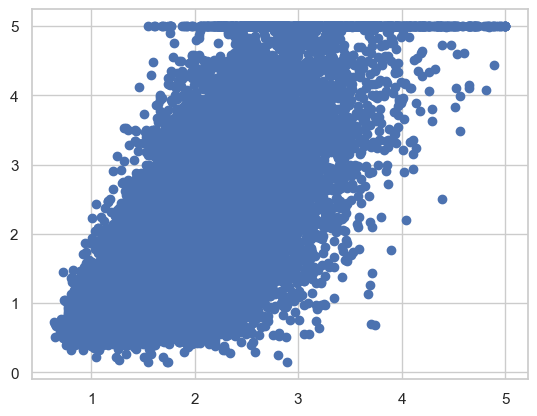

In [29]:
plt.scatter(pred, y)

# Section 3 : Hands-on Lap

### Step 1: Load a provided dataset and separate it into features X and target y.

> Uploaded and used the heart disease dataset

In [40]:
import numpy as np
import pandas as pd
import seaborn as sns

df = pd.read_csv("heart.csv")
print("Shape:", df.shape)
df.head()

Shape: (1025, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [42]:
X = df.drop("target", axis=1) # features: everything except the target
y = df["target"]
print(X)
print()
print(y)

      age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  \
0      52    1   0       125   212    0        1      168      0      1.0   
1      53    1   0       140   203    1        0      155      1      3.1   
2      70    1   0       145   174    0        1      125      1      2.6   
3      61    1   0       148   203    0        1      161      0      0.0   
4      62    0   0       138   294    1        1      106      0      1.9   
...   ...  ...  ..       ...   ...  ...      ...      ...    ...      ...   
1020   59    1   1       140   221    0        1      164      1      0.0   
1021   60    1   0       125   258    0        0      141      1      2.8   
1022   47    1   0       110   275    0        0      118      1      1.0   
1023   50    0   0       110   254    0        0      159      0      0.0   
1024   54    1   0       120   188    0        1      113      0      1.4   

      slope  ca  thal  
0         2   2     3  
1         0   0     3  
2  

### Step 2: Perform an 80/20 train/test split with a fixed random_state.

In [43]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Step 3: Confirm the shapes of X_train, X_test, y_train, y_test are consistent and print them.

In [37]:
print("Full training data shape:", X_train.shape)    # Display the dimensions of the training images
print("Full training labels shape:", y_train.shape)  # Display the dimensions of the training labels
print("Test data shape:", X_test.shape)                   # Display the dimensions of the test images
print("Test labels shape:", y_test.shape)                 # Display the dimensions of the test labels

Full training data shape: (820, 13)
Full training labels shape: (820,)
Test data shape: (205, 13)
Test labels shape: (205,)


### Step 4: In a Markdown cell, explain in your own words why the model must never see the test set during training.

In order for the model to learn the right patterns from the data, we divide the dataset into features and labels. The goal is for the model to learn how to match the input features with the correct labels. However, to know if our model is actually accurate, we keep about 20% of the dataset as a test set. The model does not see this data during training. After training, we let the model predict the labels for the test set and compare its predictions with the correct labels.
If the model saw the test set during training, it could memorize the answers instead of learning the real patterns, so the evaluation would not show how well the model performs on new unseen data.

# Section 4 : References

**Articles**
-  Sprevised learning and it's types : https://www.geeksforgeeks.org/machine-learning/supervised-machine-learning/
- Regression : https://www.geeksforgeeks.org/machine-learning/regression-in-machine-learning/
- Regression Algorithm : https://medium.com/@jennycoreholt/regression-analysis-for-beginners-finding-relationships-in-data-a2d20a07777a
- Multi-lable Classifecation : https://www.geeksforgeeks.org/machine-learning/an-introduction-to-multilabel-classification/

**Tutorials**
- More tutorials on Scikit-learn : https://calmcode.io/course/scikit-learn/introduction
   > The first 3 videos of this tutorial were implemented in this notebook